In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

In [3]:
from src.config import BEST_MODEL_PATH, DATA_PROCESSED_DIR
import joblib
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os


In [4]:
X_test = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "y_test.csv")).squeeze()

model = joblib.load(BEST_MODEL_PATH)
model

RandomForestClassifier(max_depth=4, min_samples_split=8, n_estimators=253,
                       n_jobs=-1, random_state=42)

In [5]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85        32
           1       0.79      0.93      0.86        29

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



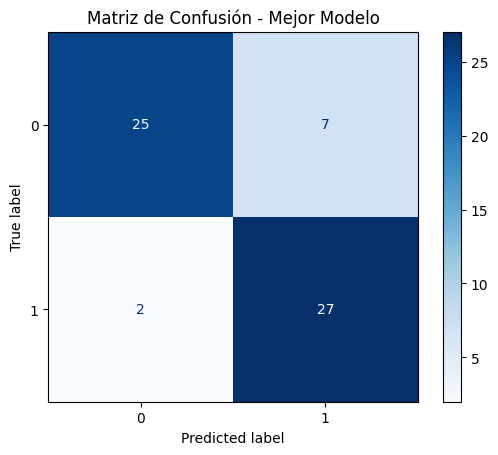

In [6]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Mejor Modelo")
plt.show()
